## Multi Instrument Plot
This tool downloads and visualizes time-series data of various instruments of a selected spacecraft including solar energetic particle intensities, solar wind plasma and magnetic field data. 

Selected remote-sensing observations such as radio spectrograms or X-ray light curves are also available.

#### Import tools and display options
GOES manual satellite selection: check to manually pick GOES satellite during data loading. When left unchecked, the highest numbered satellite is picked automatically.

Averaging options: "Averaging" averages particle data (except L1 which has its own options), "MAG averaging" averages magnetic field and plasma/solar wind quantities, and "STIX/XRS averaging" averages SolO/STIX and GOES/XRS. 0 minutes averaging means original cadence.

STIX light travel time correction means that the data are time-shifted to a distance of 1 AU. Everything else is in local time of the spacecraft.

In [1]:
import os
import datetime as dt
import matplotlib.pyplot as plt

from seppy.util import jupyterhub_data_path

import multi_inst_plots as m
from multi_inst_plots.other_tools import copy_fig_axs

In [2]:
m.options.show()

#### Data directory

Define where to download files. Running this cell will set it to \<current directory\>/data, or if run on the project's JupyterHub server, set it to a common data folder in the base directory. Setting to None will use sunpy's default data directory. 

In [14]:
m.options.path = f"{os.getcwd()}{os.sep}data"
m.options.path = jupyterhub_data_path(m.options.path)

#### Load data
Run this cell whenever spacecraft, instruments or dates are re-selected. Non-averaged data and metadata are returned should you want to use them for other purposes.

In [15]:
data, metadata = m.load_data()

Loading L1 (Wind/SOHO) data for range: 2012-01-21 00:00:00 - 2012-01-24 23:59:59
Loading Wind/3DP data... (dataset 1/5)


100%|###############################################| 441k/441k [00:00<?, ?B/s]


100%|###############################################| 604k/604k [00:00<?, ?B/s]


Loading Wind/WAVES data... (dataset 2/5)


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

soho_erne-hed_l2-1min_20120124_v01.cdf:   0%|          | 0.00/48.0k [00:00<?, ?B/s]

Loading GOES/XRS data... (dataset 5/5)
Fetching GOES-15 XRS data for 2012-01-21 00:00:00 - 2012-01-24 23:59:59


Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

sci_gxrs-l2-irrad_g15_d20120124_v0-1-0.nc:   0%|          | 0.00/849k [00:00<?, ?B/s]

Data loaded!


#### Energy channel selection
Print out energy ranges for each channel and choose the indices of the channels you want to include in your plot with `m.energy_channel_selection()`. Use `m.range_selection()` for easy range selection. Alternatively, you can choose them manually with the widgets: click+drag cursor or Shift+click for ranges, Ctrl/Cmd + click for individual channels.

In [16]:
# Display energy channel ranges and corresponding selection widgets
m.energy_channel_selection()

,3DP Electrons,3DP Protons,EPHIN Electrons,ERNE Protons
0,28.1 - 52.18 keV,137.62 - 255.58 keV,0.25 - 0.7 MeV,13 - 16 MeV
1,46.32 - 86.02 keV,233.39 - 433.44 keV,0.67 - 3.0 MeV,16 - 20 MeV
2,75.91 - 140.97 keV,386.66 - 718.09 keV,2.64 - 10.4 MeV,20 - 25 MeV
3,127.25 - 236.32 keV,712.59 - 1323.38 keV,4.80 - 10.4 MeV,25 - 32 MeV
4,216.66 - 402.36 keV,1451.67 - 2695.97 keV,NaN,32 - 40 MeV
5,361.78 - 671.87 keV,3107.7 - 5771.44 keV,NaN,40 - 50 MeV
6,<NA>,4728.47 - 8781.44 keV,NaN,50 - 64 MeV
7,<NA>,<NA>,NaN,64 - 80 MeV
8,<NA>,<NA>,NaN,80 - 100 MeV
9,<NA>,<NA>,NaN,100 - 130 MeV


In [17]:
# Pass e.g. low_e_start=0, low_p_stop=24, low_p_step=3, high_p_start=5 as arguments. Not every argument is required, 
# and the ordering doesn't matter either. Leave empty for a nice selection covering the full range.
m.range_selection()

#### Define plot range

You can optionally define a smaller plotting range here. Values have to be valid datetime objects and within loaded time range. Set to None for 00:00 - 00:00.

In [18]:
m.options.plot_start = None # dt.datetime(2022, 3, 15, 0, 0)
m.options.plot_end =  None # dt.datetime(2022, 3, 17, 0, 0)

#### Plot data
Figure and axes are returned for further tweaking capability.

Chosen energy channels:
Wind/3DP electrons: (0, 1, 2, 3, 4, 5), 6
EPHIN electrons: (0, 2), 2
Wind/3DP protons: (0, 1, 2, 3, 4, 5, 6), 7
ERNE-HED protons: (0, 2, 4, 6, 8), 5
Plotting L1 (Wind/SOHO) data for timerange 2012-01-21 00:00:00 - 2012-01-24 23:59:59


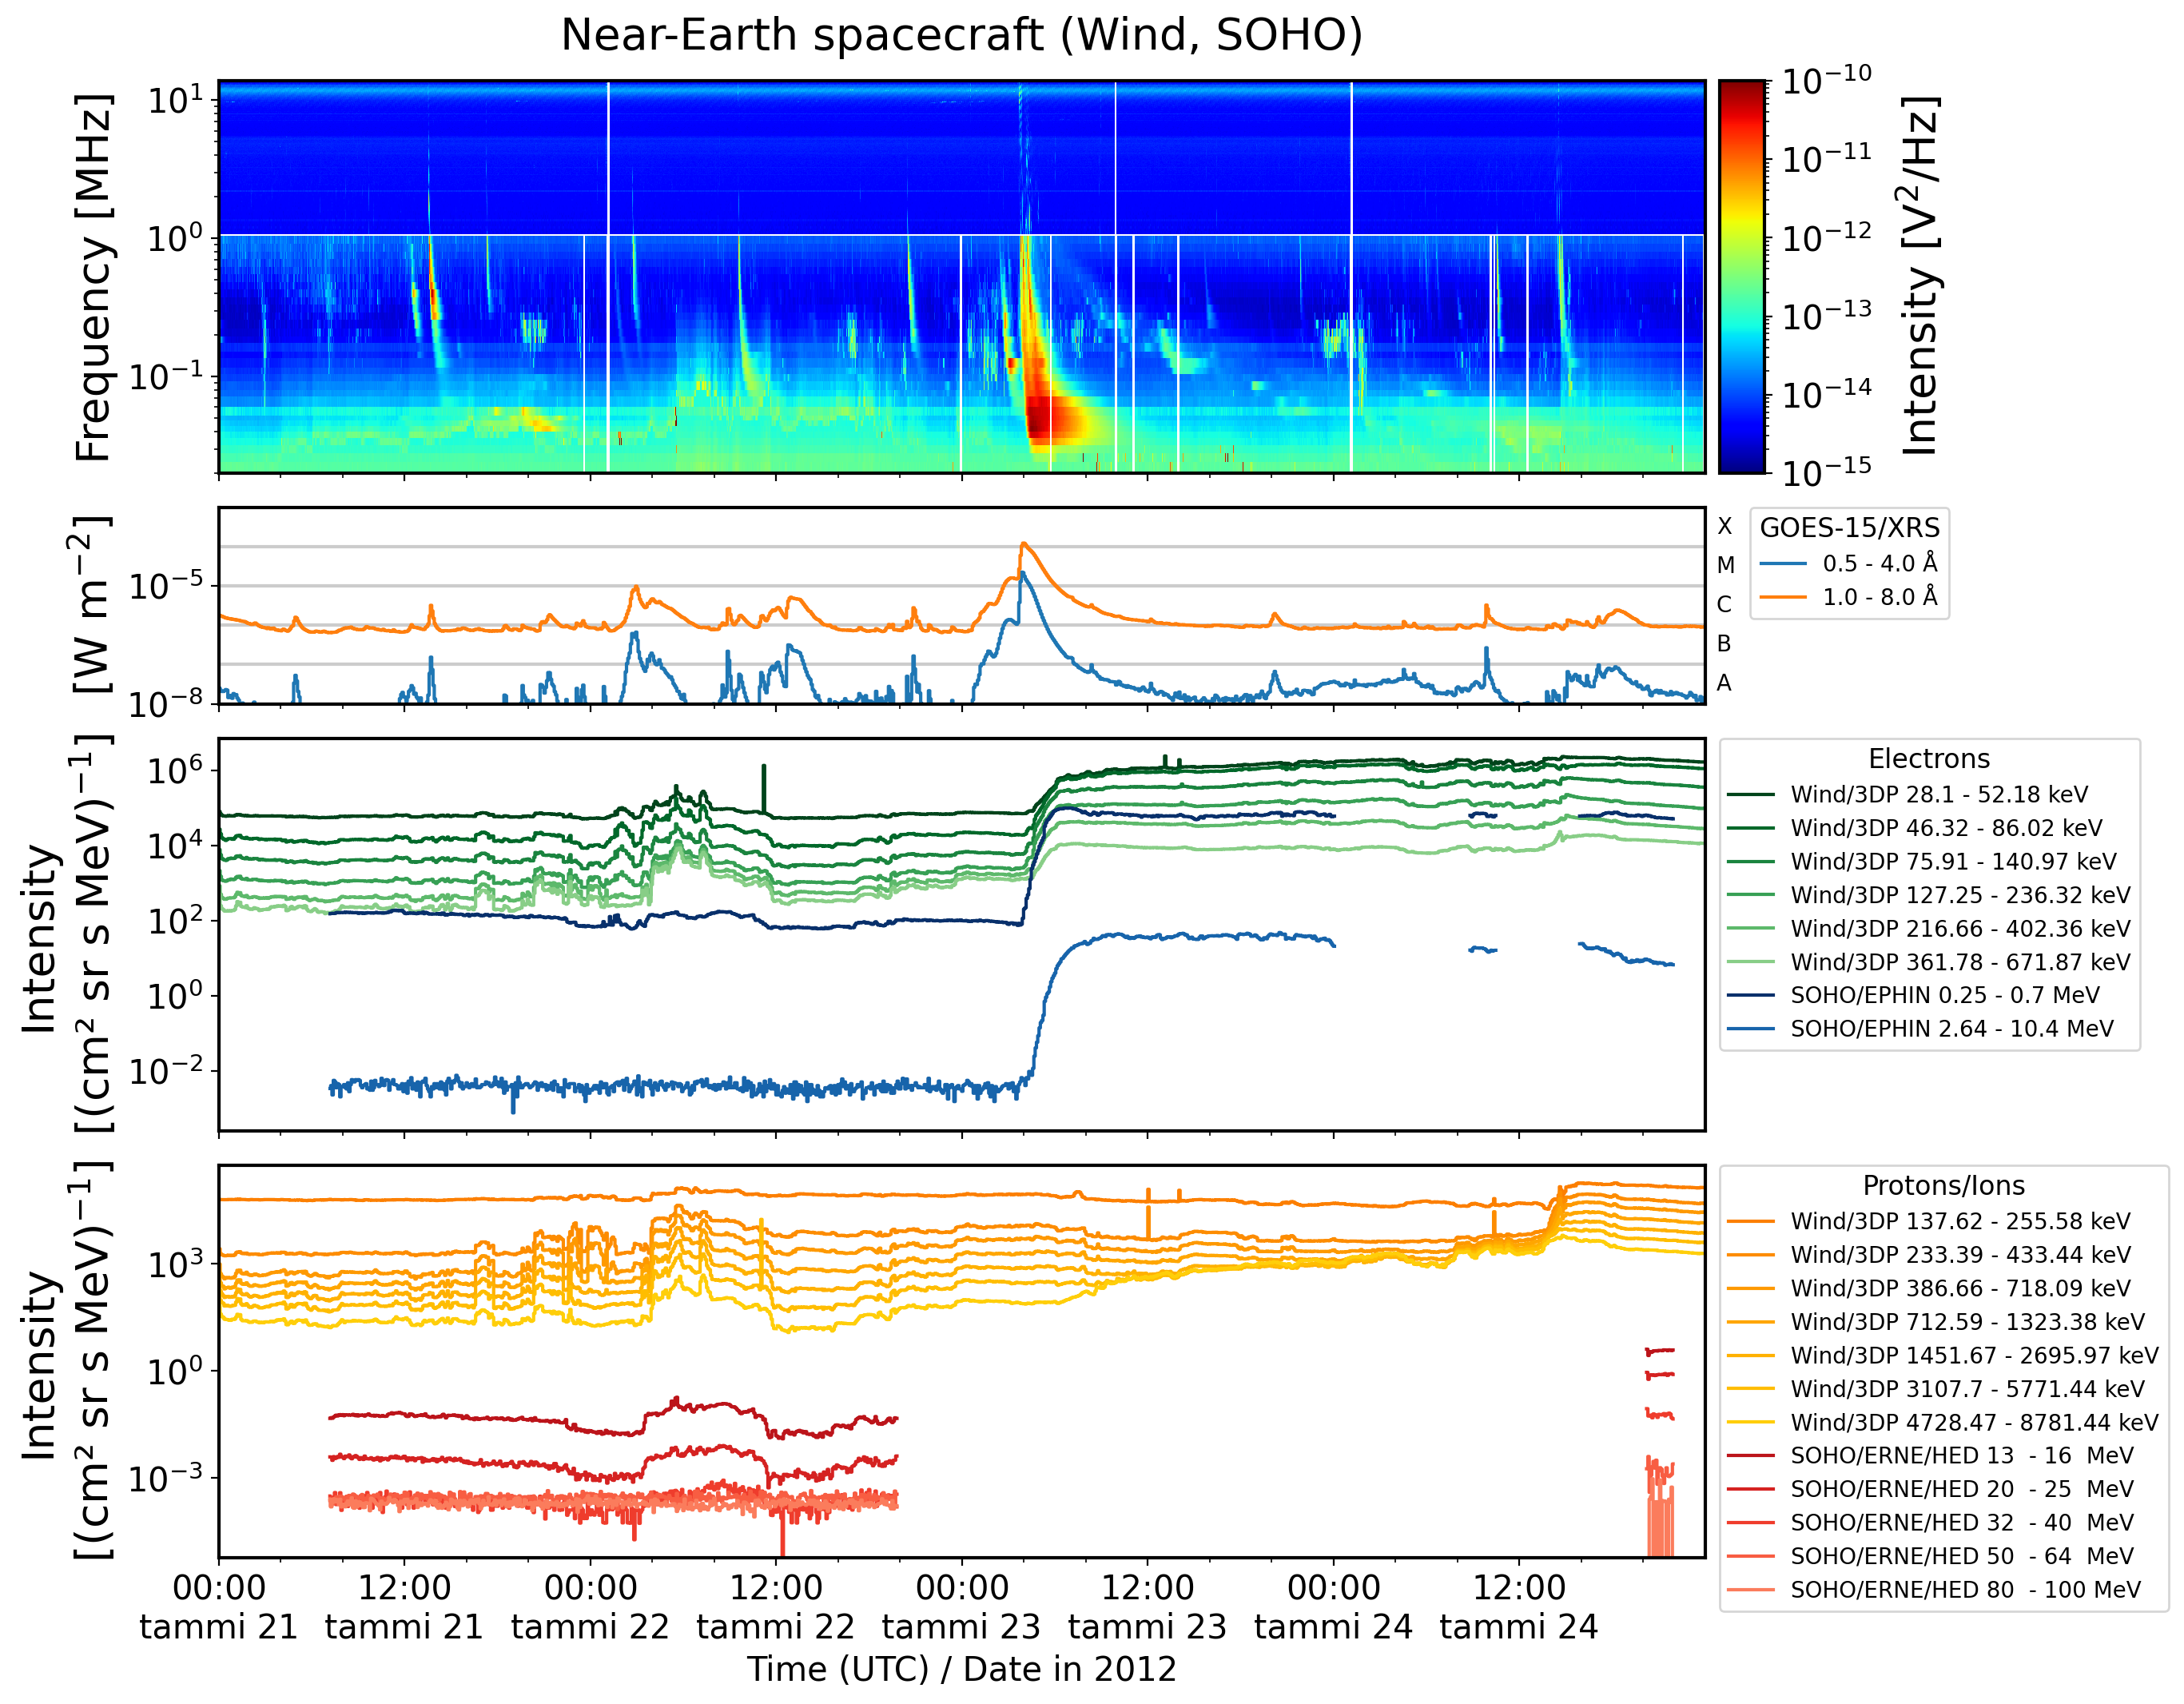

In [19]:
fig, axs = m.make_plot()

## Edit the figure
For example, add a vertical line at a given datetime or a red-shaded region in the 9th panel.

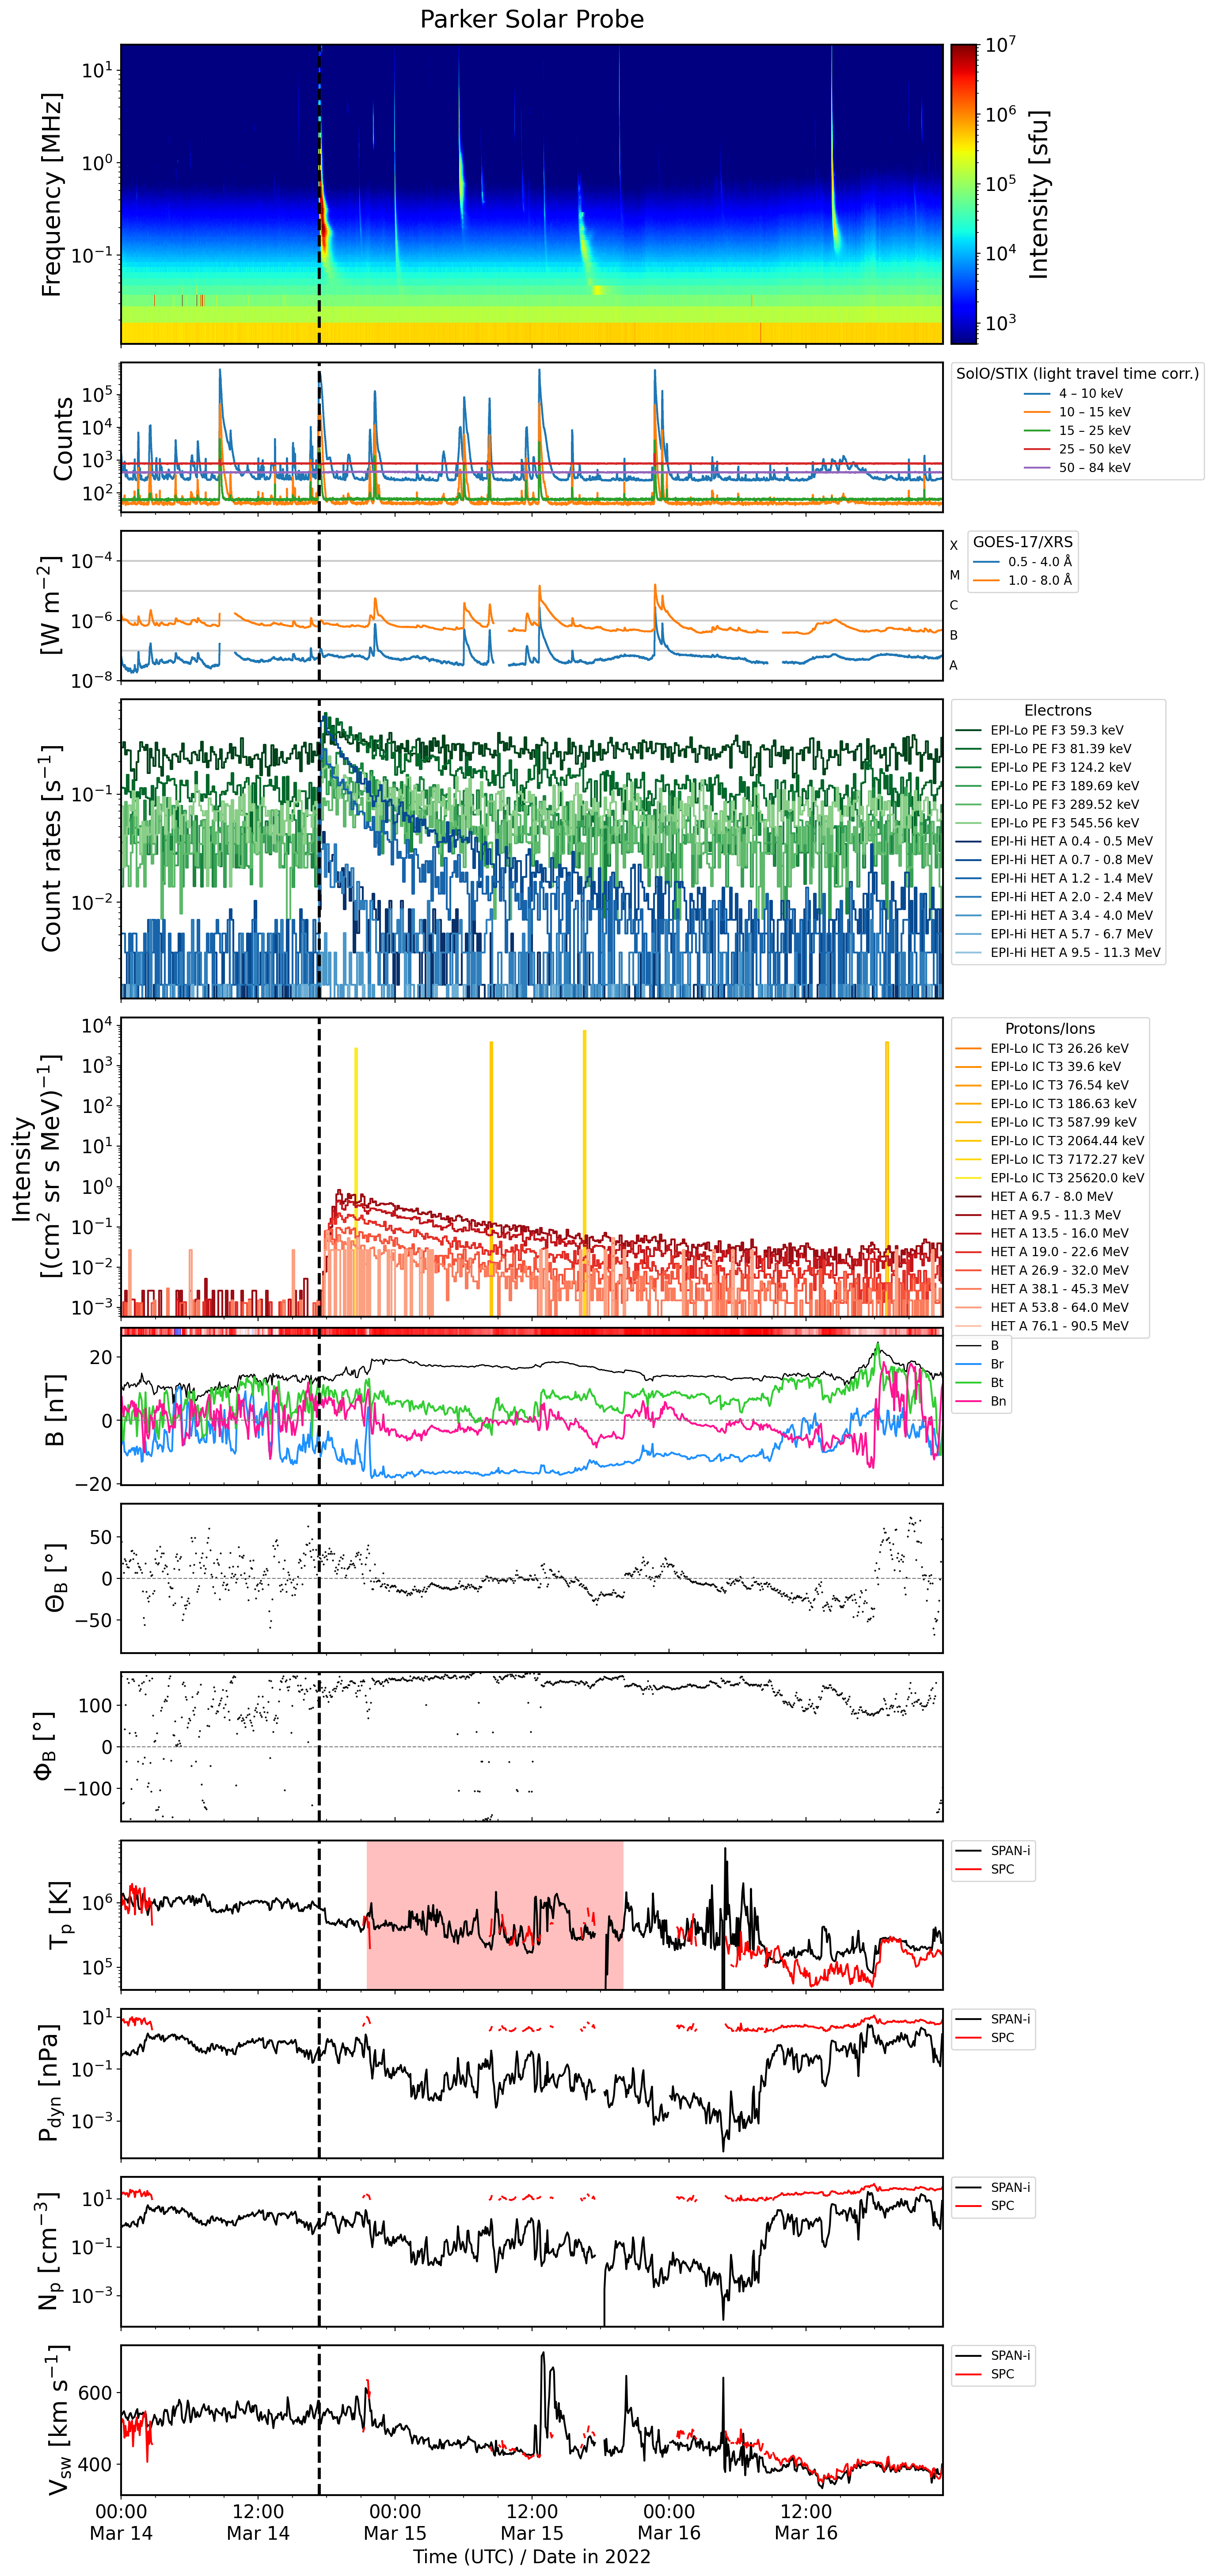

In [ ]:
# make a copy of the figure; don't change
fig_copy, axs_copy = copy_fig_axs(fig)

# vertical line 
time_vline = dt.datetime(2022, 3, 14, 17, 20)  # time format is YYYY, MM, DD, HH, SS
for ax in axs_copy:
    ax.axvline(time_vline, 
               linestyle="--",  # available line styles are '-', '--', '-.', ':'
               linewidth=2.5,
               color="black")

# shaded region in 9th panel (counting starts with 0)
cell_shade = 8
starttime_shade = dt.datetime(2022, 3, 14, 21, 30)
endtime_shade = dt.datetime(2022, 3, 15, 20, 00)
axs_copy[cell_shade].axvspan(starttime_shade, 
                             endtime_shade,
                             alpha=0.25,  # alpha value of the shading from 0.0 to 1.0 
                             facecolor="red", 
                             edgecolor=None,  # color of boundary lines
                             linestyle="-")  # linestyle only effective if edgecolor is defined  

# show updated figure; don't change
fig_copy

### Saving figures

You can usually save a figure from the Notebook by right-clicking on it while holding down the ⇧ Shift key, then select "Save Image As..." (or similar). Alternatively, run the following cell.

In [ ]:
fig_copy.savefig("SEP_multi-instrument_plot.png", bbox_inches="tight")